In [1]:
# -*- coding: utf-8 -*-
"""
Created on Wed Feb 19 15:51:54 2020

@author: wrighta
"""

import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from sympy import oo


# Input Ray parameter, i.e. height and angle
def ray(y,theta):
    '''
    Parameters
    ----------
    y : float or integer or sympy symbol in meters
        The vertical height of a ray.
    theta : float or integer in radians
        The angle of divergence of the ray.

    Returns
    -------
    mat : 2x1 matrix
        [
        [y],
        [teta]
        ]

    '''
    
    mat = np.array([[y],[theta]])
    return mat

# Ray Transfer Matrix for ideal lens with focal length f
def lens(f):
    '''
    Parameters
    ----------
    f : float or integer or sympy symbol in meters
        Thin lens focal length in meters

    Returns
    -------
    mat : 2x2 matrix
    [
    [   1, 0],
    [-1/f, 1]
    ]

    '''

    mat = np.array([[1,0], [-1/f, 1]])
    return mat

# Ray Transfer Matrix for propagation of distance d
def prop(d):
    '''
    Parameters
    ----------
    d : float or integer or sympy symbol
        Distance light is propagating along the z-axis.

    Returns
    -------
    mat: 2x2 matrix
    [
    [1, d],
    [0, 1]
    ]

    '''
    mat = np.array([[1,d], [0,1]])
    return mat


# multiplying the matrices together. mat1 is the last matrix the light interacts with
def mult(mat1,*argv):
    '''
    Parameters
    ----------
    mat1 : 2x2 ABCD matrix
        Last matrix light interacts with.
    *argv : 2x2 ABCD matrices 
        From left to right, the matrices should be entered such that the leftmost matrix interacts
        with light temporally after the rightmost matrix.

    Returns
    -------
    Mat : 2x2 matrix
        The ABCd matrix describing the whole optical system.

    '''

    Mat = mat1
    for arg in argv:
        Mat = np.dot(Mat, arg)
    return Mat

# Adding Gaussian beam parameters
def Zr(wo, lam):
    '''
    Parameters
    ----------
    wo : float, integer, or symbol
        Beam waist radius in meters.
    lam : float, integer, or symbol
        Wavelength of light in meters.

    Returns
    -------
    zr : float, int, symbols
        Rayleigh range for given beam waist and wavelength.

    '''

    zr = np.pi * wo**2 / lam
    return zr

def W0(zr, lam):
    '''
    Parameters
    ----------
    zr : float, integer, symbol
        Rayleigh range in meters
    lam : float, integer, symbol
        Wavelength of light in meters

    Returns
    -------
    w0 : float, integer, symbol
        Beam waist radius in meters

    '''

    w0 = np.sqrt(lam * zr / np.pi)
    return w0

# Remember, there should be an i in front of zr
# but this complicates the calculations, so we usually just let z = 0
# and don't explicitly deal with the i, but still do the math accordingly
#def q0_func(z,zr):
#    qz = z + zr
#    return qz

def q1_func(z, w0, lam, mat):
    '''
    Parameters
    ----------
    z : float, int, symbol
        Position of the beam waist in meters.
    w0 : float, int, symbol
        Radial waist size in meters (of the embedded Gaussian, i.e. W0/M).
    lam : float, int, symbol
        Wavelength of light in meters.
    mat : float, int, symbol
        The ABCD 2x2 matrix describing the optical system.

    Returns
    -------
    z: float, int, symbol
        Position of the beam waist after the optical system
    zr: float, int, symbol
        Rayleigh range of the beam after the optical system
    '''

    A = mat[0][0]
    B = mat[0][1]
    C = mat[1][0]
    D = mat[1][1]
    zr = Zr(w0, lam)
    real = (A*C*(z**2 + zr**2) + z*(A*D + B*C) + B*D) / (C**2*(z**2 + zr**2) + 2*C*D*z + D**2)
    imag = (zr * (A*D - B*C)) / (C**2*(z**2 + zr**2) + 2*C*D*z + D**2)
    z = real
    zr = imag
    return z, zr
    
def q1_inv_func(z, w0, lam, mat):
    '''
    Parameters
    ----------
    z : float, int, symbol
        Position of the beam waist in meters.
    w0 : float, int, symbol
        Radial waist size in meters (of the embedded Gaussian, i.e. W0/M).
    lam : float, int, symbol
        Wavelength of light in meters.
    mat : float, int, symbol
        The ABCD 2x2 matrix describing the optical system.

    Returns
    -------
    R : float, int, symbol
        Radius of curvature of the wavefront in meters.
    w : float, int, symbol
        Radius of the beam in meters.

    '''
    A = mat[0][0]
    B = mat[0][1]
    C = mat[1,0]
    D = mat[1][1]
    zr = Zr(w0, lam)
    real = (A*C*(z**2 + zr**2) + z*(A*D + B*C) + B*D) / (A**2*(z**2 + zr**2) + 2*A*B*z + B**2) 
    imag = -zr * (A*D-B*C) / (A**2 *(z**2 + zr**2) + 2*A*B*z + B**2) 
    R = 1/real
    w = (-lam / imag / np.pi)**.5
    return R, w


def plot(func, var, rang = np.arange(0,3,.01)):
    '''
    Parameters
    ----------
    func : Sympy function of one variable
        Sympy function defining the beam width after the last optical element.
    var : sympy variable
        Variable in func that will be plotted.
    rang : numpy array
        Array of the values along the optical axis to be plotted

    Returns
    -------
    plot : matplotlib graph
        Graph of the beam width of var


    '''
    func = sym.lambdify(var, func)
    plt.figure()
    plt.plot(rang, func(rang), color = 'b')
    plt.plot(rang, -func(rang), color = 'b')
    plt.grid()
    plt.xlabel('Optic Axis (m)')
    plt.ylabel('Beam size (m)')
    plt.show()

In [3]:
w0 = 1E-3 # 1mm beam waist
lam = 355E-9 # wavelength of 355 nm (UV)
zR = Zr(w0, lam) # Rayleigh range in m
z0 = 0 # location of waist in m

In [4]:
d = sym.symbols('d')
M = prop(d)

In [5]:
R, w = q1_inv_func(0, w0, lam, M)

In [6]:
print('w = {}'.format(w))

w = (1.27690021685256e-8*d**2 + 1.0e-6)**0.5


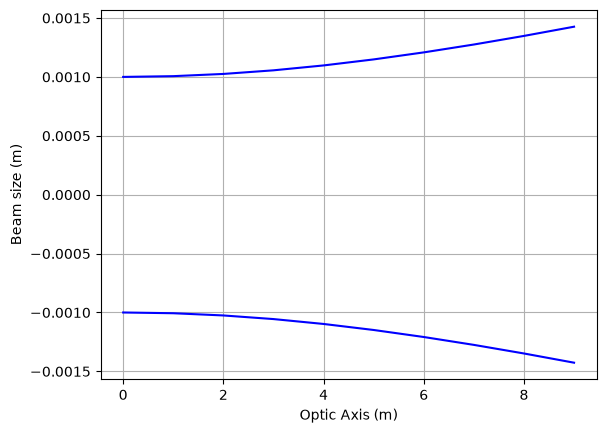

In [7]:
plot(w, d, rang = np.arange(0,10))

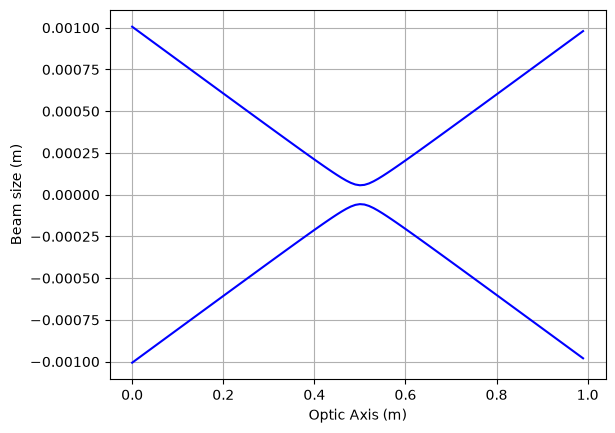

In [9]:
w0 = 1E-3 # 1mm beam waist
lam = 355E-9 # wavelength of 355 nm (UV)
zR = Zr(w0, lam) # Rayleigh range in m
z0 = 0 # location of waist in m

d = sym.symbols('d')
M = mult(prop(d), lens(.5), prop(1))
            
R, w = q1_inv_func(0, w0, lam, M)

plot(w, d, rang = np.arange(0,1,.01))

In [11]:
w0 = 1E-3 # 1mm beam waist
lam = 355E-9 # wavelength of 355 nm (UV)
zR = Zr(w0, lam) # Rayleigh range in m
z0 = 0 # location of waist in m

d1, d2, d3, f1, f2 = sym.symbols('d1 d2 d3 f1 f2')

M = mult(prop(d3),lens(f2),prop(d2), lens(f1), prop(d1))

R, w = q1_inv_func(0, w0, lam, M)

In [12]:
w = w.subs(d1,1).subs(d3,0)
f1_eq = sym.solve(w - 5*w0, f1)[0]
print('f = {}'.format(f1_eq))

f = 1.0084642216545e+15*d2*(1.12051580183833e+27*d2 - 1000000.0*sqrt(1.94972095138912e+47 - 9.83284085630607e+43*d2**2) + 8.88733242867719e+28)/(1.13000009595246e+42*d2**2 + 2.26000019190491e+42*d2 - 2.12276362486616e+45)


In [13]:
print('f1 = {:.2f} m, for a lens separation of 1 meter'.format(f1_eq.subs(d2, 1)))

f1 = 0.17 m, for a lens separation of 1 meter


In [14]:
R_coll = R.subs(d1,1).subs(d2,1).subs(f1,.17).subs(d3,0)
f2_coll = sym.solve(1/R_coll,f2)[0]
print('f2 = {:.2f}, for a collimated beam, 5x the original waist, after propagating 1m to the first lens of f1 = .17m, and propagating another 1m to the second lens'.format(f2_coll))

f2 = 0.83, for a collimated beam, 5x the original waist, after propagating 1m to the first lens of f1 = .17m, and propagating another 1m to the second lens


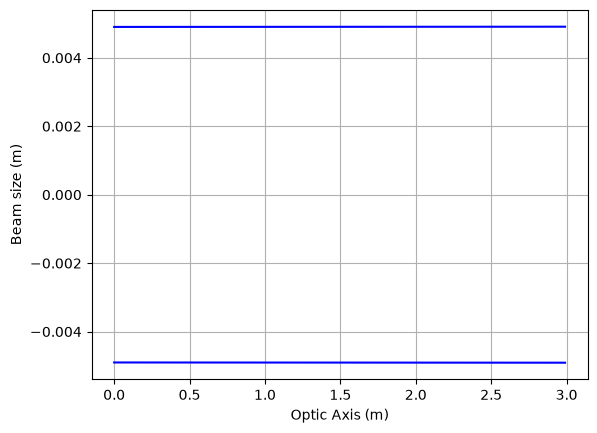

In [15]:
M = mult(prop(d3),lens(.83),prop(1), lens(.17), prop(1))

R, w = q1_inv_func(0, w0, lam, M)

plot(w,d3)

In [16]:
expansion_factor = w.subs(d3,0)/ w0
print('beam is w = {:.2f} x w0'.format(expansion_factor))

beam is w = 4.90 x w0


In [17]:
beam_size_change = (w.subs(d3,10) - w.subs(d3,0)) / w.subs(d3,0) * 100
print('Over 10 m after second lens, beam changes by {:.0f}%'.format(beam_size_change))

Over 10 m after second lens, beam changes by 1%
